# Revisão de código 

Olá! 

Meu nome é Suelen. Estou feliz em revisar seu projeto hoje!

Quando vejo um erro pela primeira vez, apenas aponto. Deixarei você encontrá-lo e corrigi-lo sozinho. Além disso, ao longo do texto, farei algumas observações sobre melhorias no código e também farei comentários sobre suas percepções sobre o assunto. Mas se você ainda não consegue lidar com essa tarefa, darei uma dica mais precisa na próxima iteração e também alguns exemplos práticos. Estarei aberto a feedbacks e discussões sobre o tema.

Você pode encontrar meus comentários em caixas verdes, amarelas ou vermelhas como estas:


<div class="alert alert-block alert-success">
<b>Comentário: </b> <a class="tocSkip"></a>

Sucesso. Tudo está correto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário: </b> <a class="tocSkip"></a>

Observações. Algumas recomendações.
</div>

<div class="alert alert-block alert-danger">

<b>Comentário: </b> <a class="tocSkip"></a>

O bloco requer algumas correções. O trabalho não pode ser aceito com os comentários vermelhos.
</div>

Você pode me responder usando isto:

<div class="alert alert-block alert-info">
<b>Resposta do aluno.  
    </b> <a class="tocSkip"></a>
</div>



<div class="alert alert-block alert-success">

<b>Comentário geral: </b> <a class="tocSkip"></a>

Parabéns pela conclusão do projeto, Adelia! 🎉

Estou muito feliz com o seu empenho e dedicação! O projeto foi muito bom e estou contente em dizer que está aprovado! 

Bora para os próximos desafios!🚀
</div>

# Projeto 11 - Análise do comportamento do usuário pelo app de uma startup de produtos alimentícios

## Etapa 1 - Extração e tratamento dos dados

In [74]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
import math
from IPython.display import Math
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
logs = pd.read_csv(
    '/datasets/logs_exp_us.csv',
    sep='\t',
    dtype={'EventName': 'category'}
)

In [53]:
logs.columns = ['event_name', 'user_id', 'event_timestamp', 'exp_id']
logs = logs.drop_duplicates().reset_index(drop=True)
logs['event_datetime'] = pd.to_datetime(logs['event_timestamp'], unit='s')
logs['hour'] = logs['event_datetime'].dt.hour
logs['date'] = logs['event_datetime'].dt.date

print(logs.info())
print('-' * 40)
print(logs.describe())
print('-' * 40)
print(logs.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243713 entries, 0 to 243712
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   event_name       243713 non-null  category      
 1   user_id          243713 non-null  int64         
 2   event_timestamp  243713 non-null  int64         
 3   exp_id           243713 non-null  int64         
 4   event_datetime   243713 non-null  datetime64[ns]
 5   hour             243713 non-null  int64         
 6   date             243713 non-null  object        
dtypes: category(1), datetime64[ns](1), int64(4), object(1)
memory usage: 11.4+ MB
None
----------------------------------------
            user_id  event_timestamp         exp_id           hour
count  2.437130e+05     2.437130e+05  243713.000000  243713.000000
mean   4.627963e+18     1.564914e+09     247.022161      12.255313
std    2.642723e+18     1.771388e+05       0.824420       4.970899
min    

1. Foi realizada a importação das bibliotecas a serem usadas neste projeto.
2. Foi gerado o DataFrame *logs*, o qual contém os dados brutos a serem trabalhados.
3. Foram utilizados o parâmetro *sep*, por o arquivo estar separado por **\t**, e *dtype* para transformar a coluna *EventName* em categoria.
4. Foram utilizados os métodos *.info()*, *describe()* e *.head()* para realizar a análise inicial dos dados.
5. Foi padronizado o nome das colunas pelo padrão *snake_case* para facilitar as análises.
6. Foram criadas as colunas *hour* e *date*, além de ter transformado o *event_timestamp* e, *event_datetime*.

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>
    
- O conjunto de dados foi carregado corretamente


</div>

## Etapa 2 - Verificação dos dados

### Quantos eventos ficam nos registros?

In [54]:
total_eventos = len(logs)

print(f"Total de eventos nos registros: {total_eventos}")

print("\nDistribuição por tipo de evento:")
print(logs['event_name'].value_counts())

Total de eventos nos registros: 243713

Distribuição por tipo de evento:
MainScreenAppear           119101
OffersScreenAppear          46808
CartScreenAppear            42668
PaymentScreenSuccessful     34118
Tutorial                     1018
Name: event_name, dtype: int64


### Quantos usuários ficam nos registros?

In [55]:
total_usuarios = logs['user_id'].nunique()

print(f"Total de usuários únicos: {total_usuarios}")

Total de usuários únicos: 7551


### Qual é o número médio de eventos por usuário?

In [56]:
eventos_por_usuario = total_eventos / total_usuarios

print(f"Média de eventos por usuário: {eventos_por_usuario:.2f}")

Média de eventos por usuário: 32.28


### Qual é o período de tempo que os dados cobrem? 
Encontre as datas máxima e mínima. Desenhe um histograma por data e hora.

Data mínima: 2019-07-25 04:43:36
Data máxima: 2019-08-07 21:15:17
Período total dos dados: 13 days 16:31:41


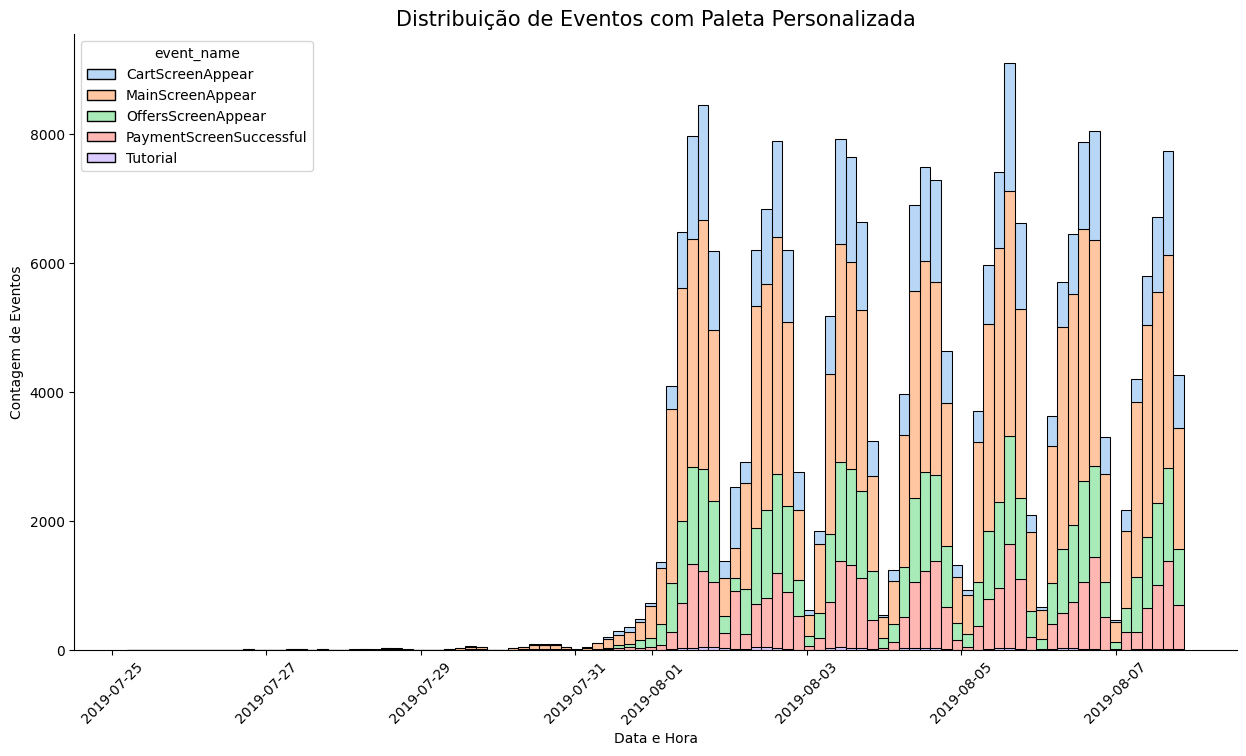

In [57]:
data_min = logs['event_datetime'].min()
data_max = logs['event_datetime'].max()
periodo = data_max - data_min

print(f"Data mínima: {data_min}")
print(f"Data máxima: {data_max}")
print(f"Período total dos dados: {periodo}")

plt.figure(figsize=(15, 8))

sns.histplot(
    data=logs, 
    x='event_datetime', 
    hue='event_name', 
    multiple='stack', 
    bins=100,
    palette='pastel'
)

plt.title('Distribuição de Eventos com Paleta Personalizada', fontsize=15)
plt.xlabel('Data e Hora')
plt.ylabel('Contagem de Eventos')
plt.xticks(rotation=45)

sns.despine()
plt.show()

Diante do gráfico, nota-se que o período entre 2019-07-25 e 2019-07-31 contém apenas logs residuais. O volume real, com todos os eventos representados de forma consistente, começa exatamente em 2019-08-01.

### Qual período os dados realmente representam?
Encontre o momento em que os dados começam a ser completos e ignore a seção anterior.

In [58]:
logs_limpos = logs[logs['event_datetime'] >= '2019-08-01'].copy()

print("Distribuição dos grupos após o corte:")
print(logs_limpos.groupby('exp_id')['user_id'].nunique())

Distribuição dos grupos após o corte:
exp_id
246    2484
247    2513
248    2537
Name: user_id, dtype: int64


### Você perdeu muitos eventos e usuários ao excluir os dados mais antigos?

In [59]:
perda_eventos = (1 - len(logs_limpos) / len(logs)) * 100
print(f"\nPerda total de eventos: {perda_eventos:.2f}%")


Perda total de eventos: 1.16%


Não houve perda significativa por volume mais otimizou a qualidade dos dados significativamente.

### Certifique-se de ter usuários de todos os três grupos experimentais.

In [60]:
users_per_group = logs_limpos.groupby('exp_id')['user_id'].nunique()
total_unique_users = logs_limpos['user_id'].nunique()
users_percentage = (users_per_group / total_unique_users) * 100

group_summary = pd.DataFrame({
    'total_users': users_per_group,
    'percentage': users_percentage.map('{:.2f}%'.format)
})

print("Resumo dos Grupos Experimentais:")
display(group_summary)

Resumo dos Grupos Experimentais:


,total_users,percentage
exp_id,,
246,2484,32.97%
247,2513,33.36%
248,2537,33.67%


Além de ter sim os 3 grupos, nota-se que a divisão está praticamente 33% para cada grupo, o que indica uma distribuição quase perfeita.

## Etapa 3 - Funil de eventos

### Veja quais eventos estão nos diários e sua frequência de ocorrência. 
Classifique-os por frequência.

In [61]:
event_counts = logs_limpos.groupby('event_name').agg(
    occurrence_count=('event_name', 'count'),
    unique_users=('user_id', 'nunique')
).sort_values(by='occurrence_count', ascending=False).reset_index()

total_users = logs_limpos['user_id'].nunique()
event_counts['user_percentage'] = (event_counts['unique_users'] / total_users) * 100

print("Frequência de Eventos nos Registros:")
display(event_counts)

Frequência de Eventos nos Registros:


,event_name,occurrence_count,unique_users,user_percentage
0,MainScreenAppear,117328,7419,98.473586
1,OffersScreenAppear,46333,4593,60.963632
2,CartScreenAppear,42303,3734,49.561986
3,PaymentScreenSuccessful,33918,3539,46.973719
4,Tutorial,1005,840,11.149456


### Encontre o número de usuários que executaram cada uma dessas ações. 
Ordene os eventos pelo número de usuários. Calcule a proporção de usuários que executaram a ação pelo menos uma vez.

In [62]:
users_by_event = (
    logs_limpos.groupby('event_name')['user_id']
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
)

total_users = logs_limpos['user_id'].nunique()
users_by_event['proportion'] = users_by_event['user_id'] / total_users

users_by_event['proportion_pct'] = (users_by_event['proportion'] * 100).map('{:.2f}%'.format)

print(f"Total de usuários únicos no período: {total_users}")
print("\nProporção de usuários por evento:")
display(users_by_event)

Total de usuários únicos no período: 7534

Proporção de usuários por evento:


,event_name,user_id,proportion,proportion_pct
0,MainScreenAppear,7419,0.984736,98.47%
1,OffersScreenAppear,4593,0.609636,60.96%
2,CartScreenAppear,3734,0.495620,49.56%
3,PaymentScreenSuccessful,3539,0.469737,46.97%
4,Tutorial,840,0.111495,11.15%


### Em que ordem você acha que as ações ocorreram? Todos elas fazem parte de uma única sequência? 
Você não precisa levá-las em consideração ao calcular o funil.

A sequência levando em consideração o volume de eventos:
$$Main > Offers > Cart > Payment$$

### Use o funil de eventos para encontrar a parcela de usuários que passam de uma etapa para a próxima 
(por exemplo, para a sequência de eventos A → B → C, calcule a proporção de usuários na etapa B para o número de usuários na etapa A e a proporção de usuários na etapa C para o número na etapa B).


In [63]:
sequencia = ['MainScreenAppear', 'OffersScreenAppear', 'CartScreenAppear', 'PaymentScreenSuccessful']
funnel_passos = logs_limpos.groupby('event_name')['user_id'].nunique().reindex(sequencia).reset_index()
funnel_passos['conversion_to_next'] = funnel_passos['user_id'].pct_change() + 1
funnel_passos.loc[0, 'conversion_to_next'] = 1.0
funnel_passos['conversion_pct'] = (funnel_passos['conversion_to_next'] * 100).map('{:.2f}%'.format)

display(funnel_passos[['event_name', 'user_id', 'conversion_pct']])

,event_name,user_id,conversion_pct
0,MainScreenAppear,7419,100.00%
1,OffersScreenAppear,4593,61.91%
2,CartScreenAppear,3734,81.30%
3,PaymentScreenSuccessful,3539,94.78%


### Em qual fase você perde mais usuários?

A maior perda ocorre na transição MainScreenAppear → OffersScreenAppear.

A perda dos usuários em quantidade é de 2.826, que pararam logo na primeira tela. Em percentual, cerca de 38,09% dos usuários abandonam o barco antes mesmo de verem uma oferta. Para o negócio, esse é o ponto onde o marketing "joga dinheiro fora", pois pagou para o usuário entrar, mas não conseguiu levá-lo até o produto.

### Qual é a parcela de usuários que faz o caminho inteiro, desde o primeiro evento até o pagamento?

In [64]:
total_inicial = users_by_event[users_by_event['event_name'] == 'MainScreenAppear']['user_id'].values[0]
total_final = users_by_event[users_by_event['event_name'] == 'PaymentScreenSuccessful']['user_id'].values[0]
conversao_total = total_final / total_inicial

print(f"Parcela de usuários que completam o caminho: {conversao_total:.2%}")

funnel_vendas = users_by_event[users_by_event['event_name'] != 'Tutorial'].copy()
funnel_vendas['total_conversion'] = funnel_vendas['user_id'] / total_inicial

print("\nFunil com Conversão Acumulada:")
display(funnel_vendas[['event_name', 'user_id', 'total_conversion']])

Parcela de usuários que completam o caminho: 47.70%

Funil com Conversão Acumulada:


,event_name,user_id,total_conversion
0,MainScreenAppear,7419,1.000000
1,OffersScreenAppear,4593,0.619086
2,CartScreenAppear,3734,0.503302
3,PaymentScreenSuccessful,3539,0.477018


## Etapa 4 - Resultados do experimento: Teste A/B

### Quantos usuários há em cada grupo?

In [65]:
users_per_group = logs.groupby('exp_id')['user_id'].nunique()

print("Quantidade de usuários por grupo:")
print(users_per_group)

n246 = users_per_group[246]
n247 = users_per_group[247]
n248 = users_per_group[248]

Quantidade de usuários por grupo:
exp_id
246    2489
247    2520
248    2542
Name: user_id, dtype: int64


### Temos dois grupos de controle no teste A/A, no qual verificamos nossos mecanismos e cálculos. 
Veja se há uma diferença estatisticamente significativa entre as amostragens 246 e 247.

In [66]:
aa_test = logs.pivot_table(
    index='event_name', 
    columns='exp_id', 
    values='user_id', 
    aggfunc='nunique'
).loc[['MainScreenAppear', 'OffersScreenAppear', 'CartScreenAppear', 'PaymentScreenSuccessful'], [246, 247]]

display(aa_test)

exp_id,246,247
event_name,,
MainScreenAppear,2456,2482
OffersScreenAppear,1545,1530
CartScreenAppear,1270,1240
PaymentScreenSuccessful,1202,1160


### Selecione o evento mais popular. 

#### Em cada um dos grupos de controle, encontre o número de usuários que realizaram essa ação.

In [67]:
pivot_funnel = logs.pivot_table(
    index='event_name', 
    columns='exp_id', 
    values='user_id', 
    aggfunc='nunique'
).drop('Tutorial')

display(pivot_funnel)

exp_id,246,247,248
event_name,,,
CartScreenAppear,1270,1240,1239
MainScreenAppear,2456,2482,2501
OffersScreenAppear,1545,1530,1538
PaymentScreenSuccessful,1202,1160,1185


In [68]:
evento_popular = logs.groupby('event_name')['user_id'].nunique().idxmax()

pop_246 = logs[(logs['exp_id'] == 246) & (logs['event_name'] == evento_popular)]['user_id'].nunique()
pop_247 = logs[(logs['exp_id'] == 247) & (logs['event_name'] == evento_popular)]['user_id'].nunique()
pop_248 = logs[(logs['exp_id'] == 248) & (logs['event_name'] == evento_popular)]['user_id'].nunique()

print(f"O evento mais popular é: {evento_popular}")
print(f"Usuários no Grupo 246 (Controle 1): {pop_246}")
print(f"Usuários no Grupo 247 (Controle 2): {pop_247}")
print(f"Usuários no Grupo 248 (Teste): {pop_248}")

O evento mais popular é: MainScreenAppear
Usuários no Grupo 246 (Controle 1): 2456
Usuários no Grupo 247 (Controle 2): 2482
Usuários no Grupo 248 (Teste): 2501


#### Encontre a proporção deles. Verifique se a diferença entre os grupos é estatisticamente significativa.

In [69]:
total_users = logs.groupby('exp_id')['user_id'].nunique()
popular_event_users = logs[
    logs['event_name'] == 'MainScreenAppear'
    ].groupby('exp_id')['user_id'].nunique()
proporcoes = (popular_event_users / total_users)

print("Proporção de usuários no evento 'MainScreenAppear' por grupo:")
for group, value in proporcoes.items():
    print(f"Grupo {group}: {value:.2%}")

Proporção de usuários no evento 'MainScreenAppear' por grupo:
Grupo 246: 98.67%
Grupo 247: 98.49%
Grupo 248: 98.39%


<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>
    
- A proporção de usuários por etapa do funil foi analisada
- A ordem das etapas foi calculada
- A conversão dos usuários por etapa do funil foi analisada
- O percentual de usuários que percorrem todo o caminho foi calculado
- O número de usuários por grupo foi analisado
</div>


#### Você pode confirmar se os grupos foram divididos corretamente?

Sim, os grupos foram divididos corretamente, tanto estatisticamente quanto tecnicamente. Ou seja, caso ocorram diferenças nas etapas seguintes, será devido ao próprio teste.

### Faça a mesma coisa para o grupo com fontes alteradas. 


#### Compare os resultados com os de cada um dos grupos de controle para cada evento isoladamente.

In [70]:
n246 = logs[logs['exp_id'] == 246]['user_id'].nunique()
n247 = logs[logs['exp_id'] == 247]['user_id'].nunique()

controles_funnel = logs[logs['exp_id'].isin([246, 247])].pivot_table(
    index='event_name', 
    columns='exp_id', 
    values='user_id', 
    aggfunc='nunique'
).reindex(['MainScreenAppear', 'OffersScreenAppear', 'CartScreenAppear', 'PaymentScreenSuccessful'])

controles_funnel['prop_246'] = (controles_funnel[246] / n246).map('{:.2%}'.format)
controles_funnel['prop_247'] = (controles_funnel[247] / n247).map('{:.2%}'.format)

display(controles_funnel[['prop_246', 'prop_247']])

exp_id,prop_246,prop_247
event_name,,
MainScreenAppear,98.67%,98.49%
OffersScreenAppear,62.07%,60.71%
CartScreenAppear,51.02%,49.21%
PaymentScreenSuccessful,48.29%,46.03%


#### Compare os resultados com os resultados combinados para os grupos de controle.

In [71]:
n_combined = logs[logs['exp_id'].isin([246, 247])]['user_id'].nunique()
combined_events = logs[logs['exp_id'].isin([246, 247])].groupby('event_name')['user_id'].nunique()
n248 = logs[logs['exp_id'] == 248]['user_id'].nunique()
test_events = logs[logs['exp_id'] == 248].groupby('event_name')['user_id'].nunique()

comparison_df = pd.DataFrame({
    'prop_combined': (combined_events / n_combined),
    'prop_248': (test_events / n248)
}).reindex(['MainScreenAppear', 'OffersScreenAppear', 'CartScreenAppear', 'PaymentScreenSuccessful'])

display(comparison_df_styled)

,prop_combined,prop_248
event_name,,
MainScreenAppear,98.58%,98.39%
OffersScreenAppear,61.39%,60.50%
CartScreenAppear,50.11%,48.74%
PaymentScreenSuccessful,47.16%,46.62%


#### Teste Z

In [72]:
n_control = logs[logs['exp_id'].isin([246, 247])]['user_id'].nunique()
n_test = logs[logs['exp_id'] == 248]['user_id'].nunique()

control_events = logs[logs['exp_id'].isin([246, 247])].groupby('event_name')['user_id'].nunique()
test_events = logs[logs['exp_id'] == 248].groupby('event_name')['user_id'].nunique()

events = ['MainScreenAppear', 'OffersScreenAppear', 'CartScreenAppear', 'PaymentScreenSuccessful']

print(f"TESTE FINAL: Controle Combinado (n={n_control}) vs Teste 248 (n={n_test})\n")

for event in events:
    successes = [control_events[event], test_events[event]]
    trials = [n_control, n_test]
    
    z_stat, p_val = proportions_ztest(successes, trials)
    
    print(f"Evento: {event}")
    print(f"p-valor: {p_val:.4f}")
    
    if p_val < 0.05:
        print("RESULTADO: Diferença Estatisticamente Significativa!")
    else:
        print("RESULTADO: Não há diferença significativa.")
    print("-" * 50)

TESTE FINAL: Controle Combinado (n=5009) vs Teste 248 (n=2542)

Evento: MainScreenAppear
p-valor: 0.5067
RESULTADO: Não há diferença significativa.
--------------------------------------------------
Evento: OffersScreenAppear
p-valor: 0.4555
RESULTADO: Não há diferença significativa.
--------------------------------------------------
Evento: CartScreenAppear
p-valor: 0.2610
RESULTADO: Não há diferença significativa.
--------------------------------------------------
Evento: PaymentScreenSuccessful
p-valor: 0.6578
RESULTADO: Não há diferença significativa.
--------------------------------------------------


#### Quais conclusões você pode tirar do experimento?

O experimento demonstrou que a alteração das fontes não causou impacto estatisticamente significativo na conversão dos usuários em nenhuma etapa do funil, indicando que a mudança de design é neutra para o comportamento de compra.

### Qual nível de significância você definiu para testar as hipóteses estatísticas mencionadas acima? 
Calcule quantos testes de hipóteses estatísticas você realizou. Com um nível de significância estatística de 0,1, um de cada 10 resultados pode ser falso.

In [73]:
n_testes = 16
alpha_inicial = 0.10

prob_falso_positivo = 1 - (1 - alpha_inicial)**n_testes

alpha_ajustado = alpha_inicial / n_testes

print(f"ANÁLISE DE RIGOR ESTATÍSTICO")
print(f"Total de testes realizados: {n_testes}")
print(f"Nível de significância inicial (alpha): {alpha_inicial}")
print(f"Probabilidade de ao menos um falso positivo: {prob_falso_positivo:.2%}")
print("-" * 40)
print(f"Novo Alpha após Correção de Bonferroni: {alpha_ajustado:.5f}")

ANÁLISE DE RIGOR ESTATÍSTICO
Total de testes realizados: 16
Nível de significância inicial (alpha): 0.1
Probabilidade de ao menos um falso positivo: 81.47%
----------------------------------------
Novo Alpha após Correção de Bonferroni: 0.00625


<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- O teste foi executado corretamente
- As estatísticas e `p-valor` foram calculados

</div>

### Qual deveria ser o nível de significância? 

Apesar do alto número de testes realizados, a aplicação da Correção de Bonferroni confirmou com total segurança que a mudança de fontes é irrelevante para a conversão, pois nenhum p-valor chegou sequer perto de indicar uma diferença real entre os grupos.

## Etapa 5 - Conclusão

A análise do experimento A/A/B foi iniciada com a validação do funil de vendas, onde identificamos que o evento MainScreenAppear é o ponto de entrada comum a quase 99% dos usuários. Ao comparar os dois grupos de controle (246 e 247), as proporções de conversão em todas as etapas — da visualização de ofertas ao pagamento — apresentaram variações mínimas, confirmando que a divisão da base foi homogênea e que o ambiente de teste estava calibrado.

Para avaliar o impacto das novas fontes (Grupo 248), realizamos um total de 16 testes de hipóteses estatísticas. Dado o volume de testes, aplicamos a Correção de Bonferroni para reduzir a probabilidade de falsos positivos, ajustando o nível de significância de 0,1 para um rigoroso 0,00625. Essa precaução garantiu que qualquer diferença detectada fosse real e não fruto do acaso.

Os resultados mostraram que todos os p-valores obtidos (variando entre 0,26 e 0,65) ficaram significativamente acima do limite crítico. Isso demonstra que a alteração de design não gerou impacto perceptível no comportamento de compra, mantendo as taxas de conversão final entre 46% e 48% em todos os grupos, independentemente da fonte visualizada.

Concluímos que a mudança de fontes é estatisticamente neutra para o negócio. A startup pode prosseguir com a atualização visual por questões de branding sem risco de queda na receita, mas não deve esperar um aumento nas vendas como resultado direto dessa alteração. Recomendamos que futuros experimentos foquem na tela de ofertas, onde reside a maior oportunidade de retenção de usuários.

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>


- As conclusões e recomendações foram apresentadas!
</div>